In [1]:
import json
from pathlib import Path

import numpy as np
import cv2
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
from PIL import Image

imginfo = lambda img: print(type(img), img.dtype, img.shape, img.min(), img.max())

In [2]:
# Load DROID or simulation data

#data_path = Path("data/clevr-act-8-clevr-rt")
data_path = Path("data/trajectory")
with open(data_path / "_annotations.all.jsonl", "r") as f:
    lines = [line.strip() for line in f.readlines()]

In [3]:
def extract_extrinsics(pose: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """
    Takes a vector [tx ty tz qw qx qy qz] and extracts 
    the translation vector (3) and the rotation matrix (3, 3)
    """
    translation = pose[:3]
    rotation = Rotation.from_quat(np.array(pose[3:]), scalar_first=True).as_matrix()
    return (translation, rotation)

def camera_to_world(t, rot):
    """
    Extrinsic matrix C from local coordinates to world coordinates.
    First rotation, then translation.
    t: (3) translation, world coordinates of local center
    rot: (3,3) rotation
    return: (4,4)
    """
    ext = np.eye(4)
    ext[0:3, 0:3] = rot
    ext[0:3, 3] = t
    return ext

def world_to_camera(t: np.ndarray, rot: np.ndarray):
    """
    t: (3) translation
    rot: (3,3) rotation
    return: (4, 4)
    """
    ext = np.eye(4)
    ext[0:3, 0:3] = rot.T
    ext[0:3, 3] = -rot.T @ t
    return ext

def project(point_3d: np.ndarray, proj: np.ndarray):
    """ 
    Multiply projection matrix by point in homogenous coordinates.
    point_3d: (3)
    proj: (3, 4)
    """
    p3d = np.ones((4))
    p3d[:3] = point_3d
    p2d = proj @ p3d # (3, 4) x (4, 1)
    p2d = p2d / p2d[2]
    return p2d[:2]

In [4]:
# === Project world to pixels:
# 1) world to camera, C^(-1)
# 2) pinhole
# 3) intrinsic
# 4) divide by last component in homogeneous coordinates

# === Total transform
# camera_intrinsic @ camera_extrinsic @ robot_transform @ correction

def load_episode(idx):
    info = json.loads(lines[idx])

    camera_intrinsic = np.array(info["camera_intrinsic"][0])
    camera_extrinsic = np.array(info["camera_extrinsic"][0])
    obj_start_pose = np.array(info["obj_end_pose"][0])

    obj_start_t, obj_start_rot = extract_extrinsics(obj_start_pose)
    image = cv2.imread(data_path / info["image"])[:,:,::-1]
    caption = info["action_text"]

    # Camera
    camera_proj = camera_intrinsic @ camera_extrinsic # (3, 3) x (3, 4), pinhole not needed

    # Robot = [tx ty tz + qw qx qy qz]
    _t = np.array([0, 0, 0.16]) # [x y z]
    _rot_euler = [0, np.pi, np.pi/2] # [rx ry rz]
    _rot = Rotation.from_euler("xyz", _rot_euler).as_matrix()
    _correction = camera_to_world(_t, _rot)
    robot_transform = camera_to_world(obj_start_t, obj_start_rot) # [4, 4]
    #robot_transform = robot_transform @ _correction

    total_transform = camera_proj @ robot_transform # (3, 4) x (4, 4)
    return [total_transform, image, caption]

In [5]:
total_transform, image, caption = load_episode(0)
print(caption)
print(total_transform)
imginfo(image)

Put the yellow block in the blue cup
[[-5.25239187e+02 -4.56267715e+02 -4.47349184e+02  5.27204425e+02]
 [ 1.08678687e+02 -2.45609464e+01 -6.32103487e+02  2.18879483e+02]
 [-2.23715603e-02 -8.29953135e-01 -5.57384343e-01  6.69594304e-01]]
<class 'numpy.ndarray'> uint8 (720, 1280, 3) 0 255


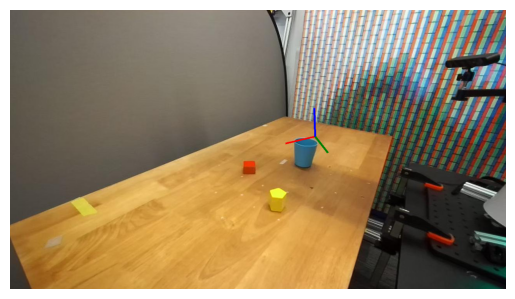

In [6]:
from PIL import ImageDraw

def show_pose(image, total_transform) -> np.ndarray:
    """
    draw the coordinate frame into each image

    Arguments:
        image: image as numpy.ndarray
        total_transform: transformation matrix from object to camera space, shape (3, 4)
            x_cam = total_transform @ x

    Returns:
        im: image as numpy.ndarray with coordinate frame drawn on it
    """
    # 1. Define 4 points in 3D homogeneous coordinates: <x, y, z, center>
    #    (The center of the coordinate system and a point for each of 3 axes.)
    #    Note that the 3D here are specified in meters.
    # 2. Transform the <x, y, z, center> coordinates into the camera frame
    # 3. Project the homogeneous coordinates <cam_x, cam_y, cam_z, center>
    #    to the camera image (euclidean)
    # 4. Draw one line for each axis

    dist = 0.1
    c = np.array([0, 0, 0])
    x = np.array([dist, 0, 0])
    y = np.array([0, dist, 0])
    z = np.array([0, 0, dist])

    c = project(c, total_transform)
    x = project(x, total_transform)
    y = project(y, total_transform)
    z = project(z, total_transform)
    # print("O", c)
    # print("X", x)
    # print("Y", y)
    # print("Z", z)

    im = Image.fromarray(image)
    draw = ImageDraw.Draw(im)
    draw.line((c[0], c[1], x[0], x[1]), fill="red", width=5)
    draw.line((c[0], c[1], y[0], y[1]), fill="green", width=5)
    draw.line((c[0], c[1], z[0], z[1]), fill="blue", width=5)

    # convert image back to numpy
    return np.asarray(im)

plot = show_pose(image, total_transform)
fig, ax = plt.subplots(1)
ax.set_axis_off()
ax.imshow(plot)

Put the yellow block in the blue cup


interactive(children=(IntSlider(value=0, description='w', layout=Layout(width='70%'), max=9), Output()), _dom_…

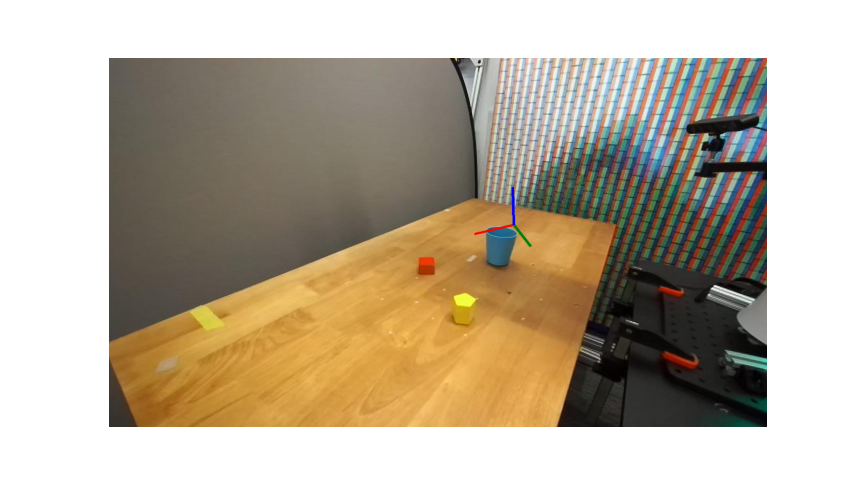

In [7]:
%matplotlib widget
from ipywidgets import widgets, Layout, interact

line = None

def update(w: int):
    global line
    total_transform, image, caption = load_episode(w)
    image_m = show_pose(image, total_transform)
    print(caption)

    if line is None:
        line = ax.imshow(image_m)
    else:
        line.set_data(image_m)
    fig.canvas.draw_idle()

image_width, image_height = int(1280/3*2), int(720/3*2)
dpi = 100
figsize = (image_width / dpi, image_height / dpi)
fig, ax = plt.subplots(1, figsize=figsize, dpi=dpi)
ax.set_axis_off()
update(0)

slider_w = widgets.IntSlider(
    min=0, max=len(lines)-1, step=1, value=0, layout=Layout(width="70%")
)
interact(update, w=slider_w)
pass